<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 1.0553 acc 0.506 | val loss 0.8532 acc 0.641 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.8809 acc 0.685 | val loss 0.7785 acc 0.694 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.38e-03 | train loss 0.8922 acc 0.646 | val loss 0.5639 acc 0.747 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.38e-03 | train loss 0.7178 acc 0.733 | val loss 0.7869 acc 0.618


...

[EfficientNet-B0] Epoch  18/100 | LR: 1.38e-03 | train loss 0.4887 acc 0.838 | val loss 0.7454 acc 0.676


[EfficientNet-B0] Epoch  19/100 | LR: 1.38e-03 | train loss 0.4155 acc 0.863 | val loss 0.3945 acc 0.794


[EfficientNet-B0] Epoch  20/100 | LR: 1.38e-03 | train loss 0.4431 acc 0.849 | val loss 0.4876 acc 0.800


[EfficientNet-B0] Epoch  21/100 | LR: 1.38e-03 | train loss 0.4319 acc 0.849 | val loss 0.4348 acc 0.794


[EfficientNet-B0] Epoch  22/100 | LR: 1.38e-03 | train loss 0.3779 acc 0.848 | val loss 0.4182 acc 0.806

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 22.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3859)


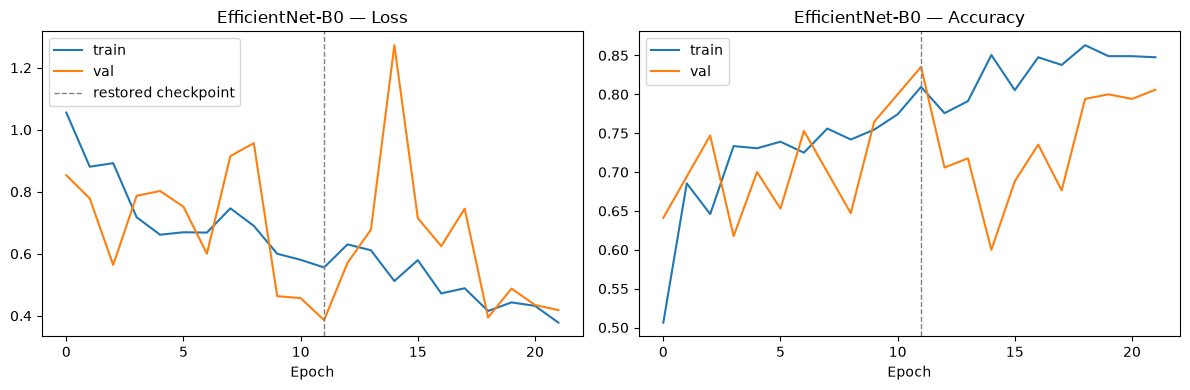

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.696


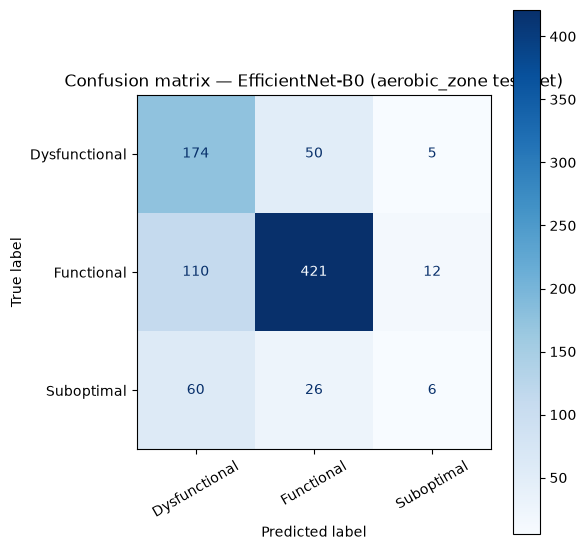

               precision    recall  f1-score   support

Dysfunctional      0.506     0.760     0.607       229
   Functional      0.847     0.775     0.810       543
   Suboptimal      0.261     0.065     0.104        92

     accuracy                          0.696       864
    macro avg      0.538     0.533     0.507       864
 weighted avg      0.694     0.696     0.681       864



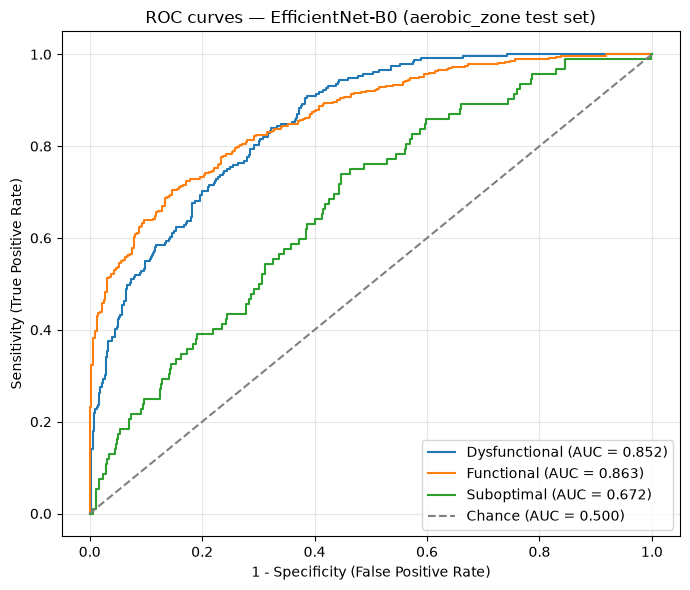

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.852
  Functional     : 0.863
  Suboptimal     : 0.672

Mean AUC (over 3/3 classes with test examples): 0.795


(np.float64(0.6956018518518519),
 {'Dysfunctional': 0.8516315373242102,
  'Functional': 0.8625439608038875,
  'Suboptimal': 0.671927799053841})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_efficientnet_b0_Waterval.pkl


Saved model weights to ../models/aerobic_zone_efficientnet_b0_cnn.pt
